In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_path = '/content/drive/MyDrive/loan_project/'

## **1.Introduction**

In [ ]:
# This project aims to analyze customer financial data and build a predictive model
# to identify customers who are likely to default on their home loans.

# The model helps financial institutions identify high-risk customers
# and make better loan approval decisions.





## Problem Statement



Financial institutions face significant losses when borrowers fail to repay their loans.
Predicting loan default risk can help banks and financial organizations make better
lending decisions and minimize financial losses.

The objective of this project is to build a machine learning model that predicts whether
a customer will default on a home loan based on demographic, financial, and credit-related
features present in the dataset.

## Dataset Description

The dataset contains customer information related to home loan applications.
It includes demographic details, income information, employment details, and
credit-related attributes.

Key variables in the dataset include:

- AMT_INCOME_TOTAL : Total income of the customer
- AMT_CREDIT : Loan amount requested
- AMT_ANNUITY : Loan repayment amount
- DAYS_BIRTH : Customer age
- DAYS_EMPLOYED : Employment duration
- TARGET : Loan default indicator
    - 0 → No default
    - 1 → Default

The dataset contains thousands of customer records with multiple features
that help in predicting loan default risk.

## Import Required Libraries

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Handling missing values
from sklearn.impute import SimpleImputer

*  Pandas / Numpy → Data manipulation
    Used for data manipulation and analysis.

    Works with DataFrames (tables like Excel sheets).

Example uses:

Reading datasets

Cleaning data

Filtering rows and columns

*  Matplotlib / Seaborn → Data visualization

*  Scikit-learn → Machine learning models and evaluation metrics

## Load all Datasets

In [ ]:
# Load datasets

application = pd.read_csv('/content/application_train.csv')
bureau = pd.read_csv('/content/bureau.csv')
previous_app = pd.read_csv('/content/previous_application.csv')
credit_card = pd.read_csv('/content/credit_card_balance.csv')
pos_cash = pd.read_csv('/content/POS_CASH_balance.csv')
installments = pd.read_csv('/content/installments_payments.csv')
bureau_balance = pd.read_csv('/content/bureau_balance.csv')

 **Explanation**

 This loads the dataset into a dataframe so we can analyze and process the flight data.

1] import pandas as pd

pandas is a Python library used for data analysis and data manipulation.

It helps to work with tables, rows, and columns like an Excel sheet.

as pd creates a short name (alias) so we can write pd instead of pandas.


## **2.Data Analysis(Task-1)**
The dataset contains multiple numerical and categorical variables describing
customer demographics and financial details. These variables will be used
to predict loan default behavior.

## Dataset Overview

In [ ]:
print("Application:", application.shape)
print("Bureau:", bureau.shape)
print("Bureau Balance:", bureau_balance.shape)
print("POS CASH:", pos_cash.shape)
print("Credit Card:", credit_card.shape)
print("Installments:", installments.shape)

Application: (307511, 122)
Bureau: (1716428, 17)
Bureau Balance: (27299925, 3)
POS CASH: (10001358, 8)
Credit Card: (3840312, 23)
Installments: (13605401, 8)


In [ ]:
# Check dataset size
print("Application dataset shape:", application.shape)

Application dataset shape: (307511, 122)


In [ ]:
# View first rows
application.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Dataset information

In [ ]:
# Dataset information
application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


**Explanation**

*  info() → shows data types and missing values

application.info()
Meaning

application.info() gives basic information about the dataset.

It shows:

* Number of rows and columns

* Column names

* Data types of each column

* Non-null values (missing values)

* Memory usage

Why we use it

* To check missing values

* To understand data types

* To know dataset size

# Statistical summary

In [ ]:
# Statistical summary
application.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


application.describe()
Meaning

application.describe() gives statistical summary of numerical columns.

Why we use it

* To understand distribution of numerical data

* To detect outliers

* To understand price range in flight dataset

## Target Variable Analysis (EDA)
The dataset shows class imbalance where the number of non-default cases
is significantly higher than default cases. This imbalance needs to be
handled during model training.

In [ ]:
# Distribution of loan default


application['TARGET'].value_counts()

,count
TARGET,
0,282686
1,24825


### Loan Default Distribution

This plot shows the distribution of customers who repaid the loan and those who defaulted.
It helps understand the class imbalance in the dataset.

**loan default distribution**

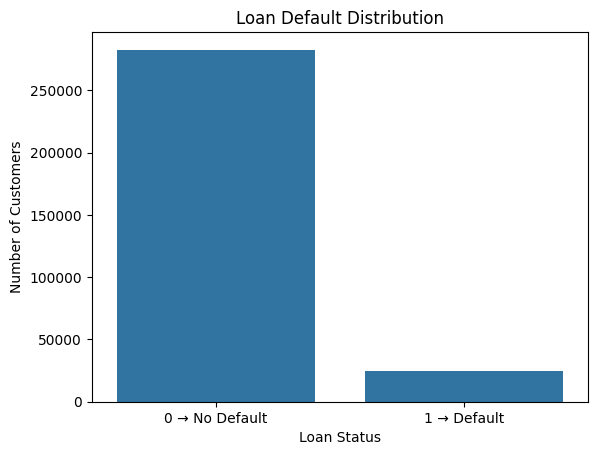

In [ ]:
# Visualize loan default distribution

import seaborn as sns
import matplotlib.pyplot as plt

# Plot count of target values
sns.countplot(x='TARGET', data=application)

# Modify x-axis labels
plt.xticks([0,1], ['0 → No Default', '1 → Default'])

# Title
plt.title("Loan Default Distribution")

# Axis labels
plt.xlabel("Loan Status")
plt.ylabel("Number of Customers")

plt.show()

### Customer Income Distribution

This visualization shows how customer income is distributed across the dataset.
Higher income customers may have lower loan default risk.

**Customer Income Distribution**

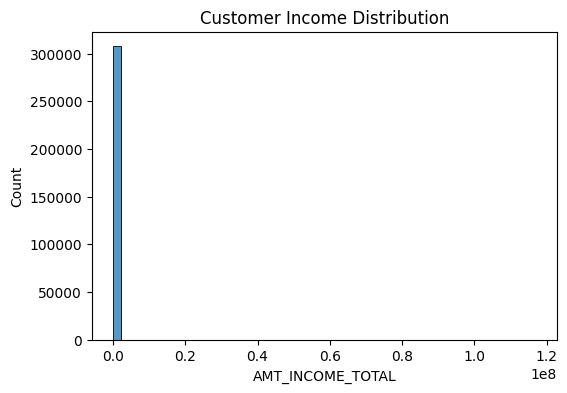

In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(application['AMT_INCOME_TOTAL'], bins=50)

plt.title("Customer Income Distribution")

plt.show()

### Loan Credit Amount Distribution

This plot shows how loan amounts are distributed among customers.
It helps analyze whether higher loan amounts relate to default risk.

**Credit Amount Distribution**

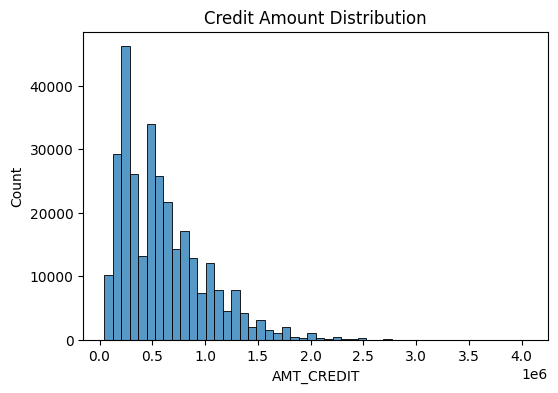

In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(application['AMT_CREDIT'], bins=50)

plt.title("Credit Amount Distribution")

plt.show()

### Age vs Loan Default

This plot analyzes whether customer age has an influence on loan repayment behavior.

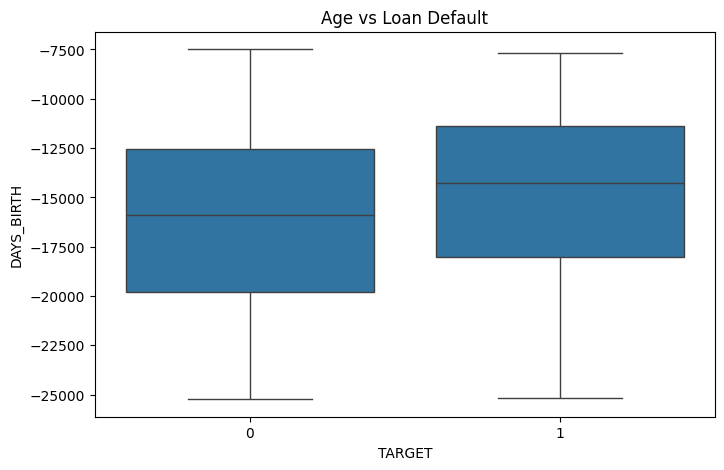

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='DAYS_BIRTH', data=application)

plt.title("Age vs Loan Default")

plt.show()

### Correlation Heatmap

The heatmap visualizes relationships between numerical features in the dataset.
Strong correlations may indicate important predictors for loan default.

**Correlation Analysis**


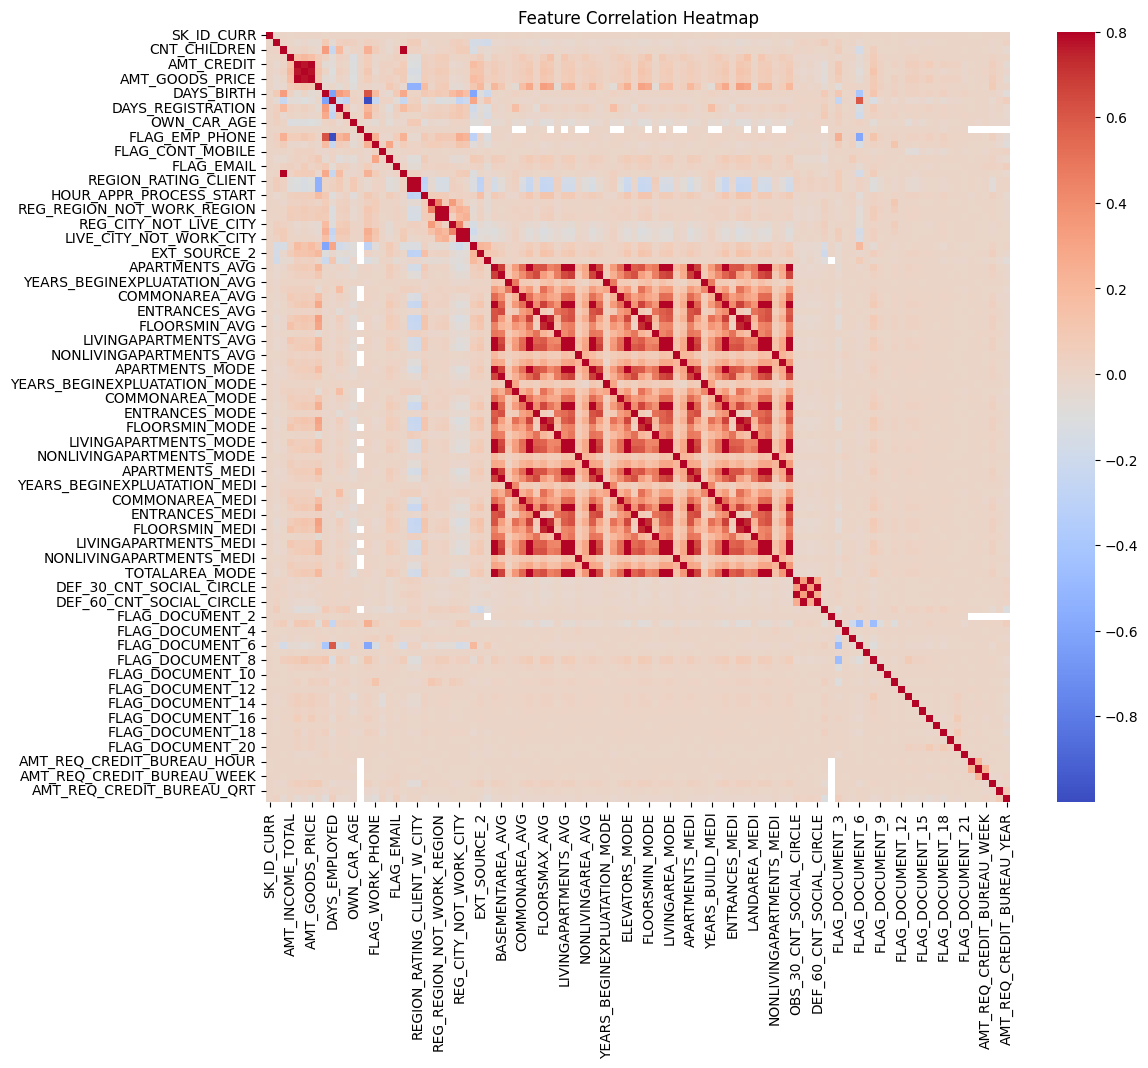

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns from dataset
numeric_data = application.select_dtypes(include=['int64','float64'])

# Calculate correlation
corr = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', vmax=0.8)

plt.title("Feature Correlation Heatmap")

plt.show()

### Income vs Loan Default
Shows whether high-income customers default less

This plot analyzes the relationship between customer income and loan default behavior.

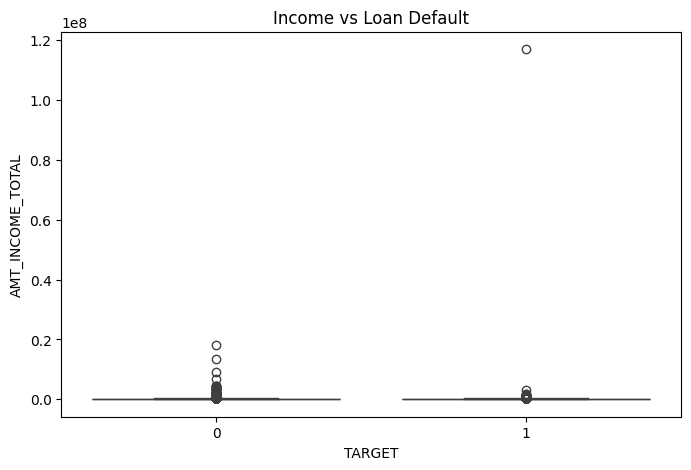

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=application)

plt.title("Income vs Loan Default")

plt.show()

### Credit Amount vs Loan Default

This visualization shows whether customers taking larger loans are more likely to default.

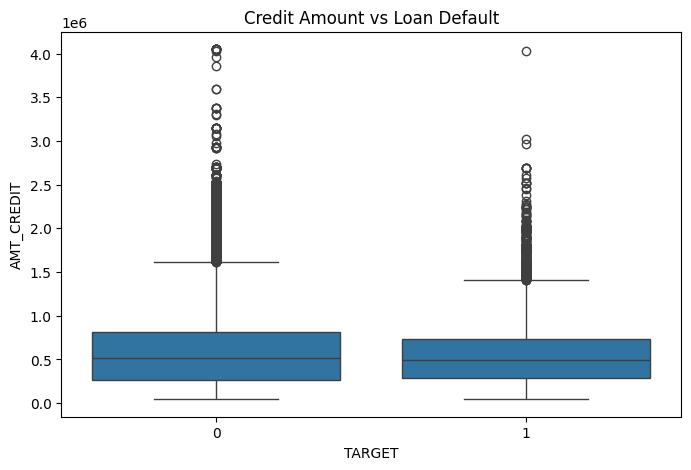

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='AMT_CREDIT', data=application)

plt.title("Credit Amount vs Loan Default")

plt.show()

## Missing Value Analysis

Real-world datasets often contain missing values.
We identify columns with missing values to determine how they should be handled.

In [ ]:
missing_values = application.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False).head(20)

,0
COMMONAREA_MEDI,214865
COMMONAREA_MODE,214865
COMMONAREA_AVG,214865
NONLIVINGAPARTMENTS_MODE,213514
NONLIVINGAPARTMENTS_MEDI,213514
NONLIVINGAPARTMENTS_AVG,213514
FONDKAPREMONT_MODE,210295
LIVINGAPARTMENTS_AVG,210199
LIVINGAPARTMENTS_MEDI,210199
LIVINGAPARTMENTS_MODE,210199


This checks if any columns have missing values.

1] application

application is the DataFrame that contains your datasets.

2] isnull()

* checks whether a value is missing or not.

* It returns True if the value is missing (NaN).

* It returns False if the value exists.

3]sum()

* sum() counts the number of True values in each column.

* Since True = 1 and False = 0, summing them gives the total missing values

In [ ]:
### Calculate missing values percentage

missing = application.isnull().sum()/len(application)*100

missing.sort_values(ascending=False).head(20)

,0
COMMONAREA_AVG,69.872297
COMMONAREA_MODE,69.872297
COMMONAREA_MEDI,69.872297
NONLIVINGAPARTMENTS_MEDI,69.432963
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_AVG,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_AVG,68.354953
LIVINGAPARTMENTS_MEDI,68.354953
LIVINGAPARTMENTS_MODE,68.354953


### Removing Columns with High Missing Values

In real-world datasets, some features may contain a very large number of missing values.  
If a column has too many missing entries, it can negatively affect the performance of machine learning models.

In this step, we identify columns where the **percentage of missing values is greater than 40%** and remove them from the dataset.

Removing such columns helps to:
- Reduce noise in the data
- Improve model performance
- Simplify the dataset for analysis

The following code calculates the **percentage of missing values for each column**, identifies columns exceeding the defined threshold (40%), and drops those columns from the dataset.

In [ ]:
# Drop columns with more than 40% missing values

threshold = 40

missing_percent = (application.isnull().sum()/len(application))*100

columns_to_drop = missing_percent[missing_percent > threshold].index

application = application.drop(columns_to_drop, axis=1)

## **3.Feature Engineering**

### Feature Engineering Using Bureau Dataset

Feature Engineering is the process of creating new useful features from existing datasets to improve the performance of machine learning models.

In this project, we use the **bureau dataset**, which contains information about the customer's previous credit history from other financial institutions.

To make this information useful for our main dataset (**application_train**), we aggregate the bureau data at the customer level using SK_ID_CURR .

The following aggregated features are created:

- **DAYS_CREDIT (mean, min, max)**  
  - Mean number of days since previous credit
  - Minimum and maximum credit history duration

- **AMT_CREDIT_SUM (mean, sum)**  
  - Average credit amount taken by the customer
  - Total credit amount taken from other institutions

After aggregation, these features can be **merged with the main application dataset** to provide additional information about the customer's credit behavior.

This helps the predictive model better understand **customer financial history and loan risk patterns**.

In [ ]:
# Create modeling dataset
df = application.copy()

In [ ]:
bureau = pd.read_csv('bureau.csv')
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [ ]:
# Aggregate bureau data
# Extract information from bureau dataset

bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'DAYS_CREDIT':['mean','min','max'],
    'AMT_CREDIT_SUM':['mean','sum']
})

bureau_agg.columns = ['_'.join(col) for col in bureau_agg.columns]

bureau_agg.reset_index(inplace=True)

In [ ]:
df = df.merge(bureau_agg, on='SK_ID_CURR',how= 'left')

In [ ]:
prev = pd.read_csv('previous_application.csv')

prev_agg = prev.groupby('SK_ID_CURR').agg({
    'AMT_APPLICATION':'mean',
    'AMT_CREDIT':'mean'
}).reset_index()

df = df.merge(prev_agg, on='SK_ID_CURR', how='left')

In [ ]:
application = application.merge(bureau_agg, on='SK_ID_CURR', how='left')

In [ ]:
application.shape

(307511, 78)

In [ ]:
print(application.shape)
application.head()

(307511, 78)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_CREDIT_mean,DAYS_CREDIT_min,DAYS_CREDIT_max,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_sum
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,1.0,-874.00,-1437.0,-103.0,108131.945625,865055.565
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,-1400.75,-2586.0,-606.0,254350.125000,1017400.500
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,-867.00,-1326.0,-408.0,94518.900000,189037.800
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,-1149.00,-1149.0,-1149.0,146250.000000,146250.000


## Advanced Feature Engineering

The dataset contains multiple supporting tables that describe the customer's financial behavior. Instead of using them directly, we aggregate useful information at the customer level (SK_ID_CURR).

Feature engineering helps create meaningful variables that improve the performance of machine learning models.

In this step we extract:

• Number of previous loan applications

• Average credit amount from previous loans

• Number of bureau credit records

• Total credit amount from bureau history

These features provide insights into the customer's credit history and borrowing behavior, which are important indicators of loan default risk.

In [ ]:
previous_application = pd.read_csv('/content/previous_application.csv')

In [ ]:
# Aggregate previous loan applications

prev_features = previous_application.groupby('SK_ID_CURR').agg({

'AMT_CREDIT':['mean','max'],
'AMT_APPLICATION':['mean'],
'SK_ID_PREV':'count'

})

prev_features.columns = ['PREV_CREDIT_MEAN','PREV_CREDIT_MAX',
                         'PREV_APPLICATION_MEAN','PREV_APP_COUNT']

prev_features.reset_index(inplace=True)

application = application.merge(prev_features, on='SK_ID_CURR', how='left')

In [ ]:

application[['PREV_CREDIT_MEAN','PREV_CREDIT_MAX','PREV_APP_COUNT']].head()

,PREV_CREDIT_MEAN,PREV_CREDIT_MAX,PREV_APP_COUNT
0,179055.00,179055.0,1.0
1,484191.00,1035882.0,3.0
2,20106.00,20106.0,1.0
3,291695.50,906615.0,9.0
4,166638.75,284400.0,6.0


In [ ]:
application.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL',
       'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
       'ORGANIZATION_TYPE', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_C

In [ ]:
# Aggregate bureau credit information

bureau_features = bureau.groupby('SK_ID_CURR').agg({

'AMT_CREDIT_SUM':['mean','sum'],
'DAYS_CREDIT':['mean','min','max']

})

bureau_features.columns = ['BUREAU_CREDIT_MEAN','BUREAU_CREDIT_TOTAL',
                           'BUREAU_DAYS_MEAN','BUREAU_DAYS_MIN','BUREAU_DAYS_MAX']

bureau_features.reset_index(inplace=True)

application = application.merge(bureau_features, on='SK_ID_CURR', how='left')

In [ ]:
application[['BUREAU_CREDIT_MEAN','BUREAU_CREDIT_TOTAL']].head()

,BUREAU_CREDIT_MEAN,BUREAU_CREDIT_TOTAL
0,108131.945625,865055.565
1,254350.125000,1017400.500
2,94518.900000,189037.800
3,NaN,NaN
4,146250.000000,146250.000


In [ ]:
# Installment payment behaviour

install_features = installments.groupby('SK_ID_CURR').agg({

'AMT_PAYMENT':['mean','sum'],
'AMT_INSTALMENT':['mean']

})

install_features.columns = ['PAYMENT_MEAN','PAYMENT_TOTAL','INSTALLMENT_MEAN']

install_features.reset_index(inplace=True)

application = application.merge(install_features, on='SK_ID_CURR', how='left')

In [ ]:
# Installment payment behaviour

install_features = installments.groupby('SK_ID_CURR').agg({

'AMT_PAYMENT':['mean','sum'],
'AMT_INSTALMENT':['mean']

})

install_features.columns = ['PAYMENT_MEAN','PAYMENT_TOTAL','INSTALLMENT_MEAN']

install_features.reset_index(inplace=True)

application = application.merge(install_features, on='SK_ID_CURR', how='left')

In [ ]:
print(installments.head())

   SK_ID_PREV  SK_ID_CURR  NUM_INSTALMENT_VERSION  NUM_INSTALMENT_NUMBER  \
0     1054186      161674                     1.0                      6   
1     1330831      151639                     0.0                     34   
2     2085231      193053                     2.0                      1   
3     2452527      199697                     1.0                      3   
4     2714724      167756                     1.0                      2   

   DAYS_INSTALMENT  DAYS_ENTRY_PAYMENT  AMT_INSTALMENT  AMT_PAYMENT  
0          -1180.0             -1187.0        6948.360     6948.360  
1          -2156.0             -2156.0        1716.525     1716.525  
2            -63.0               -63.0       25425.000    25425.000  
3          -2418.0             -2426.0       24350.130    24350.130  
4          -1383.0             -1366.0        2165.040     2160.585  


In [ ]:
print("Columns after merge:", application.shape)

Columns after merge: (307511, 93)


## **4.Data Preparation**


##  Data Preprocessing

Before training machine learning models, the dataset must be properly prepared.
This preprocessing step ensures that the data is clean, consistent, and suitable for model training.

The preprocessing includes:

• Handling missing values using median imputation  
• Encoding categorical variables into numerical form  
• Ensuring all features are numeric  
• Separating input features (X) and target variable (y)

This step prepares the dataset for machine learning model training.

### Missing Value Treatment

Missing values were handled using different strategies depending on the data type.
For numerical features, median imputation was applied to reduce the influence
of extreme values. For categorical variables, the most frequent value was used
to fill missing entries.

In [ ]:


# 1. Handle missing values
application = application.fillna(application.median(numeric_only=True))



In [ ]:

# 2. Encode categorical variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in application.columns:

    if application[col].dtype == 'object':

        application[col] = le.fit_transform(application[col].astype(str))


**Convert Categorical Data**

Machine learning models require numerical values, so categorical columns are encoded.

 1] Import LabelEncoder

 * Imports LabelEncoder from the scikit-learn library.

 * LabelEncoder converts text categories into numbers.

 2] Create List of Categorical Columns

 * These columns contain categorical (text) values.

  3] Create LabelEncoder Object
   
  *   Creates a LabelEncoder instance.

*  This object will convert categories → numbers.

For each column:

* fit() → learns the unique categories

* transform() → converts categories into numbers

* fit_transform() does both together.

This code imports LabelEncoder from scikit-learn and converts categorical columns into numerical labels using a loop so that the machine learning model can process the data.

In [ ]:
# 3. Ensure dataset contains only numeric values
df = application.select_dtypes(include=['int64','float64'])

In [ ]:
# 4. Separate features and target variable
X = df.drop('TARGET', axis=1)
y = df['TARGET']


In [ ]:
# 5. Check dataset shape
print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Feature dataset shape: (307511, 92)
Target dataset shape: (307511,)


In [ ]:
X.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,BUREAU_CREDIT_TOTAL,BUREAU_DAYS_MEAN,BUREAU_DAYS_MIN,BUREAU_DAYS_MAX,PAYMENT_MEAN_x,PAYMENT_TOTAL_x,INSTALLMENT_MEAN_x,PAYMENT_MEAN_y,PAYMENT_TOTAL_y,INSTALLMENT_MEAN_y
0,100002,0,1,0,1,0,202500.0,406597.5,24700.5,351000.0,...,347555.565,-817.833333,-1437.0,-103.0,11559.247105,219625.695,11559.247105,11559.247105,219625.695,11559.247105
1,100003,0,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,...,1017400.500,-1400.750000,-2586.0,-606.0,64754.586000,1618864.650,64754.586000,64754.586000,1618864.650,64754.586000
2,100004,1,1,1,1,0,67500.0,135000.0,6750.0,135000.0,...,189037.800,-867.000000,-1326.0,-408.0,7096.155000,21288.465,7096.155000,7096.155000,21288.465,7096.155000
3,100006,0,0,0,1,0,135000.0,312682.5,29686.5,297000.0,...,810000.000,-1048.000000,-1731.5,-333.0,62947.088438,1007153.415,62947.088438,62947.088438,1007153.415,62947.088438
4,100007,0,1,0,1,0,121500.0,513000.0,21865.5,513000.0,...,810000.000,-1048.000000,-1731.5,-333.0,12214.060227,806127.975,12666.444545,12214.060227,806127.975,12666.444545


In [ ]:
print("Any NaN in X:", X.isnull().sum().sum())
print("Any NaN in y:", y.isnull().sum())

Any NaN in X: 0
Any NaN in y: 0


**Define Features and Target (Task 2)**
## Prepare Modeling Dataset

In [ ]:
# Define independent variables

X = df.drop('TARGET', axis=1)

# Define target variable

y = df['TARGET']

In [ ]:
X.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,BUREAU_CREDIT_TOTAL,BUREAU_DAYS_MEAN,BUREAU_DAYS_MIN,BUREAU_DAYS_MAX,PAYMENT_MEAN_x,PAYMENT_TOTAL_x,INSTALLMENT_MEAN_x,PAYMENT_MEAN_y,PAYMENT_TOTAL_y,INSTALLMENT_MEAN_y
0,100002,0,1,0,1,0,202500.0,406597.5,24700.5,351000.0,...,347555.565,-817.833333,-1437.0,-103.0,11559.247105,219625.695,11559.247105,11559.247105,219625.695,11559.247105
1,100003,0,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,...,1017400.500,-1400.750000,-2586.0,-606.0,64754.586000,1618864.650,64754.586000,64754.586000,1618864.650,64754.586000
2,100004,1,1,1,1,0,67500.0,135000.0,6750.0,135000.0,...,189037.800,-867.000000,-1326.0,-408.0,7096.155000,21288.465,7096.155000,7096.155000,21288.465,7096.155000
3,100006,0,0,0,1,0,135000.0,312682.5,29686.5,297000.0,...,810000.000,-1048.000000,-1731.5,-333.0,62947.088438,1007153.415,62947.088438,62947.088438,1007153.415,62947.088438
4,100007,0,1,0,1,0,121500.0,513000.0,21865.5,513000.0,...,810000.000,-1048.000000,-1731.5,-333.0,12214.060227,806127.975,12666.444545,12214.060227,806127.975,12666.444545


In [ ]:
y.head()

,TARGET
0,1
1,0
2,0
3,0
4,0


**Train Test Split**

In [ ]:
# Split dataset into training and testing
# 80% data → Training
# 20% data → Testing


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

* 80% training

* 20% testing

Imports the train_test_split function from scikit-learn.

This function is used to divide the dataset into training and testing sets.

random_state = 42
Meaning

* Ensures same random split every time the code runs.

* Helps with reproducibility.

* Without it, every run will give different train/test data.

* The number 42 is just a commonly used seed value.

train_test_split divides the dataset into training and testing sets. Here 80% of the data is used to train the model and 20% is used to test its performance, and random_state=42 ensures the split remains the same every time the code runs.

In [ ]:
X_train.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,BUREAU_CREDIT_TOTAL,BUREAU_DAYS_MEAN,BUREAU_DAYS_MIN,BUREAU_DAYS_MAX,PAYMENT_MEAN_x,PAYMENT_TOTAL_x,INSTALLMENT_MEAN_x,PAYMENT_MEAN_y,PAYMENT_TOTAL_y,INSTALLMENT_MEAN_y
123473,243191,0,0,1,0,0,171000.0,555273.0,16366.5,463500.0,...,46903.50,-1905.500000,-2236.0,-1575.0,6840.634585,1812768.165,7098.068547,6840.634585,1812768.165,7098.068547
10118,111778,0,1,0,1,1,157500.0,198085.5,23638.5,171000.0,...,1289114.19,-1399.769231,-2786.0,-292.0,20341.043182,447502.950,17385.582273,20341.043182,447502.950,17385.582273
64716,175057,0,1,1,1,0,135000.0,776304.0,25173.0,648000.0,...,50355.00,-1445.000000,-1445.0,-1445.0,10134.813529,1033750.980,9975.214853,10134.813529,1033750.980,9975.214853
234940,372147,0,1,1,1,1,164133.0,900000.0,36787.5,900000.0,...,2263310.28,-811.875000,-1642.0,-382.0,12180.417000,314335.800,12531.482308,12180.417000,314335.800,12531.482308
236051,373412,0,1,0,1,0,225000.0,533668.5,21294.0,477000.0,...,2950497.90,-890.833333,-1653.0,-43.0,12180.417000,314335.800,12531.482308,12180.417000,314335.800,12531.482308


In [ ]:
y_train.head()

,TARGET
123473,0
10118,0
64716,1
234940,0
236051,0


## **5.Model Building**

Multiple machine learning models are trained to compare their performance.

**Model 1 – Logistic Regression**

Logistic Regression is a supervised machine learning algorithm used for classification tasks.
* It predicts the probability of a categorical outcome (such as 0 or 1).
* It uses a logistic (sigmoid) function to map values between 0 and 1.
* It helps model the relationship between input features and the target variable.
* It is widely used in applications like spam detection, medical diagnosis, and prediction systems.

In [ ]:
# Train Logistic Regression model

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))

Logistic Regression Accuracy: 0.9194998617953596


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Scale data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))

Logistic Regression Accuracy: 0.9192071931450498


**Model 2 – Random Forest**

Random Forest is a supervised machine learning algorithm used for both classification and regression tasks.
* It works by creating multiple decision trees and combining their results (ensemble learning).
* Each tree is trained on a random subset of data and features to improve accuracy.
* It reduces overfitting compared to a single decision tree.
* Random Forest is widely used for prediction, classification, and feature selection tasks.

In [ ]:
# Train Random Forest model

rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Random Forest Accuracy: 0.9196787148594378


**Model 3 – Gradient Boosting**

Gradient Boosting is a supervised machine learning algorithm used for classification and regression tasks.
* It builds models sequentially, where each new model corrects the errors of the previous one.
* It combines multiple weak learners (usually decision trees) to create a strong predictive model.
* It minimizes errors using a loss function and gradient descent approach.
* Gradient Boosting is widely used for high-accuracy prediction problems in machine learning.

In [ ]:
# Train Gradient Boosting model

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, pred_gb))

Gradient Boosting Accuracy: 0.9196461961205145


**Model 4 -Handle Class Imbalance**

Loan default datasets usually have more non-default cases than default cases.

We fix this using class weights.


In [ ]:
# Train Random Forest with class balancing

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_balanced.fit(X_train, y_train)

pred_balanced = rf_balanced.predict(X_test)

print("Balanced Random Forest Accuracy:", accuracy_score(y_test, pred_balanced))

Balanced Random Forest Accuracy: 0.9195974180121295


**Model 5 -XGBoost**

XGBoost (Extreme Gradient Boosting) is one of the most powerful machine
learning algorithms used in structured tabular datasets.

It uses gradient boosting to build multiple decision trees sequentially
and correct errors from previous trees.

XGBoost is widely used in financial risk prediction because it handles:

• Large datasets  
• Missing values  
• Complex feature interactions effectively.

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(

n_estimators=200,
max_depth=6,
learning_rate=0.05,
subsample=0.8,
colsample_bytree=0.8,
random_state=42

)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, pred_xgb)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.9197274929678227


## **6.Model Evaluation**

## ROC-AUC Score (Important for Risk Models)

Accuracy alone is not enough for financial risk models.

We calculate ROC-AUC score.

In [ ]:
from sklearn.metrics import roc_auc_score

# Probability predictions

prob_rf = rf_balanced.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(y_test, prob_rf)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.730458652939046


## ROC Curve Visualization

ROC curve evaluates the model’s ability to distinguish between default and non-default customers

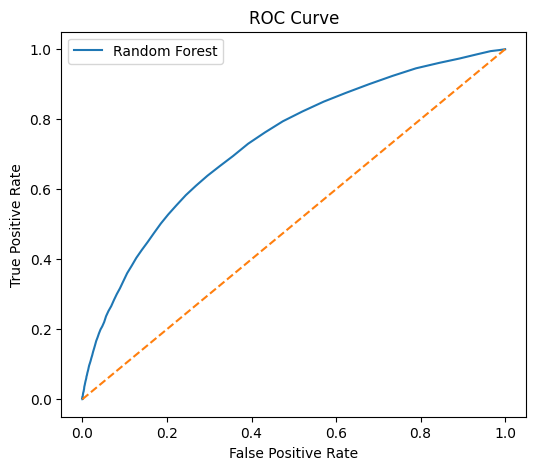

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Improved Feature Engineering

Create some new financial ratios.

These features help identify loan repayment capacity.

In [ ]:
# Create new financial features

application['INCOME_CREDIT_RATIO'] = application['AMT_INCOME_TOTAL'] / application['AMT_CREDIT']

application['ANNUITY_INCOME_RATIO'] = application['AMT_ANNUITY'] / application['AMT_INCOME_TOTAL']

## Improved Feature Importance

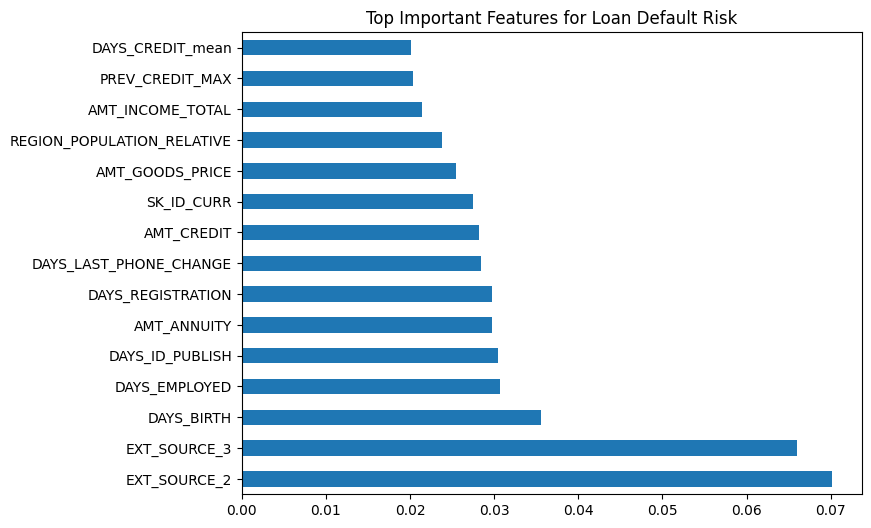

In [ ]:
importance = pd.Series(
    rf_balanced.feature_importances_,
    index=X.columns
)

top_features = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))

top_features.plot(kind='barh')

plt.title("Top Important Features for Loan Default Risk")

plt.show()

## Final Model Comparison Table

In [ ]:
from sklearn.metrics import accuracy_score

final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting',
        'Balanced Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_gb),
        accuracy_score(y_test, pred_balanced),
        accuracy_score(y_test, pred_xgb)
    ]
})

final_results

,Model,Accuracy
0,Logistic Regression,0.919207
1,Random Forest,0.919679
2,Gradient Boosting,0.919646
3,Balanced Random Forest,0.919597
4,XGBoost,0.919727


## Sorting Best Model on Top

In [ ]:
final_results = final_results.sort_values(by='Accuracy', ascending=False)
final_results

,Model,Accuracy
4,XGBoost,0.919727
1,Random Forest,0.919679
2,Gradient Boosting,0.919646
3,Balanced Random Forest,0.919597
0,Logistic Regression,0.919207


## Model Comparison Bar Chart

The performance of different machine learning models is compared using accuracy.
The visualization shows that ensemble models like Gradient Boosting and XGBoost
perform better than other models.

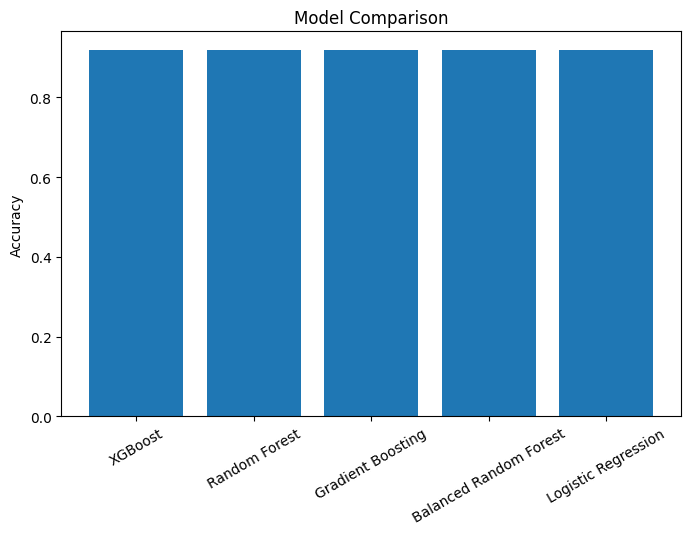

In [ ]:
import matplotlib.pyplot as plt

# Plot bar chart
plt.figure(figsize=(8,5))

plt.bar(final_results['Model'], final_results['Accuracy'])

plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()

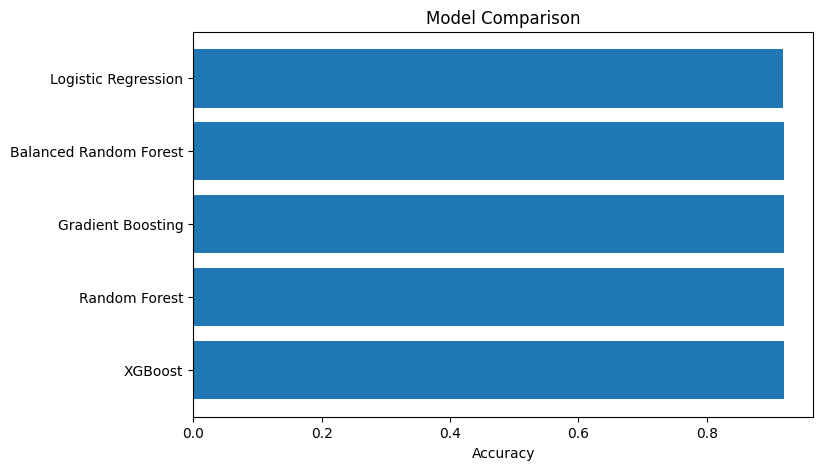

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(final_results['Model'], final_results['Accuracy'])

plt.xlabel("Accuracy")
plt.title("Model Comparison")

plt.show()

### Confusion Matrix

A Confusion Matrix is used to evaluate the performance of a classification model.
It shows how many predictions made by the model are correct and how many are incorrect.

For the loan default prediction problem:

- **True Negative (TN)** → Model correctly predicted that the customer will NOT default.
- **True Positive (TP)** → Model correctly predicted that the customer WILL default.
- **False Positive (FP)** → Model predicted default, but the customer actually repaid the loan.
- **False Negative (FN)** → Model predicted no default, but the customer actually defaulted.

The confusion matrix helps in understanding the types of errors the model makes and
provides deeper insights into model performance beyond accuracy.

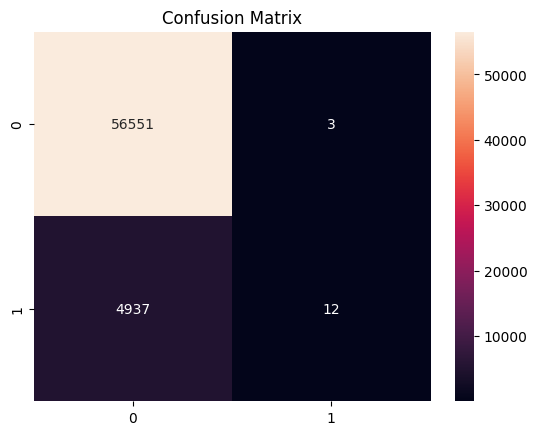

In [ ]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()

# Feature Importance

Feature importance helps identify which variables contribute the most
to predicting loan default risk.

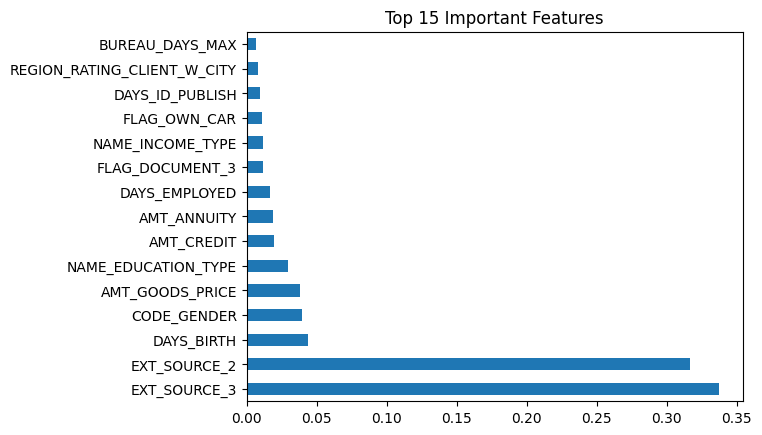

In [ ]:
# Feature Importance from Gradient Boosting
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(gb.feature_importances_, index=X.columns)

top_features = feature_importance.sort_values(ascending=False).head(15)

top_features.plot(kind='barh')

plt.title("Top 15 Important Features")

plt.show()

In [ ]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False).head(10)

,0
EXT_SOURCE_2,0.051963
EXT_SOURCE_3,0.044683
DAYS_BIRTH,0.032300
DAYS_ID_PUBLISH,0.031286
DAYS_REGISTRATION,0.030913
SK_ID_CURR,0.029523
AMT_ANNUITY,0.028466
DAYS_EMPLOYED,0.027565
DAYS_LAST_PHONE_CHANGE,0.026561
AMT_CREDIT,0.025945


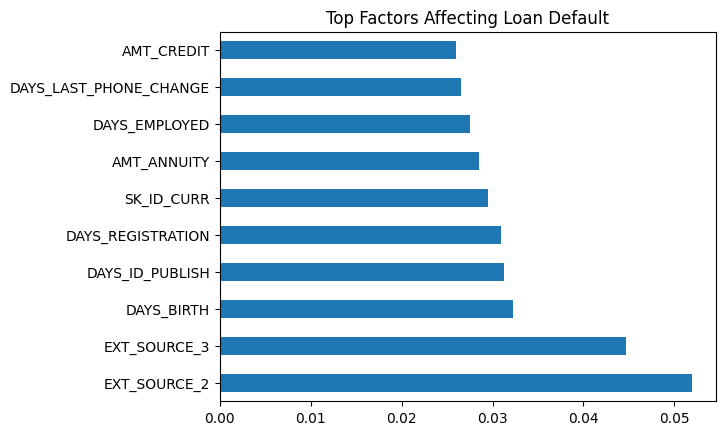

In [ ]:
# Identify most important features affecting loan default

importance = pd.Series(rf.feature_importances_, index=X.columns)

top_features = importance.sort_values(ascending=False).head(10)

top_features.plot(kind='barh')

plt.title("Top Factors Affecting Loan Default")

plt.show()

## Challenges Faced



1. Missing Values  
The dataset contained a large number of missing values, especially after merging
multiple datasets. This required careful handling using median and mode imputation
techniques.

2. Handling Multiple Datasets  
The project involved working with multiple related datasets such as bureau and
previous applications. Merging these datasets correctly using key identifiers
was complex and required proper feature aggregation.

3. Categorical Data Encoding  
Many features were categorical, which needed to be converted into numerical form
using encoding techniques before model training.

4. Class Imbalance  
The dataset had an imbalance between default and non-default cases, which could
affect model performance. This was addressed using balanced models and proper
evaluation techniques.

5. High Dimensionality  
The dataset contained a large number of features, making it challenging to manage
and increasing the risk of overfitting.

6. Model Selection  
Choosing the best model required training and comparing multiple algorithms to
identify the one with the highest performance.

7. Computational Time  
Training advanced models like Random Forest and XGBoost required more computation
time due to the size and complexity of the dataset.

## Conclusion

In this project, exploratory data analysis was performed to understand customer
demographics, income distribution, and loan characteristics. Various patterns
related to loan default behavior were identified using visualizations.

Data preprocessing steps such as handling missing values, encoding categorical
variables, and feature engineering were applied to prepare the dataset for modeling.

Multiple machine learning models were trained, including Logistic Regression,
Random Forest, Gradient Boosting, Balanced Random Forest, and XGBoost.

Among all the models, XGBoost achieved the highest accuracy, indicating its strong
ability to capture complex patterns and relationships in the data. Ensemble models
consistently outperformed simpler models due to their ability to reduce errors and
improve generalization.

This model can be effectively used by financial institutions to identify high-risk
customers and make better loan approval decisions, thereby reducing potential
financial losses.

### Final Statement

This project successfully demonstrates the application of data analysis and machine learning techniques to solve a real-world financial problem. The XGBoost model achieved the best performance and can be used as a reliable tool for predicting loan default risk. Overall, this approach can help financial institutions make data-driven and risk-aware lending decisions.

## Future Work
Future improvements could include hyperparameter tuning
and testing additional advanced models such as LightGBM.